# Smart City AI Project's EDA

## Objective:

The goal is to analyze, clean, prepare, and feature engineering the dataset

# Setep

Import the necessary libraries for data processing of the dataset

In [59]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Sklearn - evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Processed Data

In [60]:
city_df = pd.read_csv("../data/raw/smart_city_csvs/city_traffic_accidents.csv")


# City DF Data Overview

Analyze the structure, data types, and completeness of the dataset

In [61]:
# Display the rows of the dataset
city_df.head()

# Show dataset structure with the columns names and data types
city_df.info()

# Summary of the statistics for numerical columns
city_df.describe()

# Check for missing values in each column (Important)
city_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  str    
 1   Source                 500000 non-null  str    
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  str    
 4   End_Time               500000 non-null  str    
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                280022 non-null  float64
 8   End_Lng                280022 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            500000 non-null  str    
 11  Street                 499346 non-null  str    
 12  City                   499972 non-null  str    
 13  County                 500000 non-null  str    
 14  State                  500000 non-null  str    

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  219978
End_Lng                  219978
Distance(mi)                  0
Description                   0
Street                      654
City                         28
County                        0
State                         0
Zipcode                     118
Country                       0
Timezone                    476
Airport_Code               1514
Weather_Timestamp          7842
Temperature(F)            10700
Wind_Chill(F)            129188
Humidity(%)               11371
Pressure(in)               9170
Visibility(mi)            11482
Wind_Direction            11382
Wind_Speed(mph)           36902
Precipitation(in)        142366
Weather_Condition         11300
Amenity                       0
Bump                          0
Crossing

## Data Quality Results

The dataset contains 500,000 records and 46 features. The target variable (Severity) has no missing values, but there are several features contain missing data, especially the End_lat & End_lng that has around 44% missing.


In [62]:
city_df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,280022.000000,280022.000000,500000.000000,489300.000000,370812.000000,488629.000000,490830.000000,488518.000000,463098.000000,357634.000000
mean,2.212386,36.205450,-94.706816,36.269349,-95.712652,0.558359,61.657263,58.223946,64.802873,29.536751,9.090389,7.689107,0.008308
std,0.487531,5.076753,17.383787,5.269770,18.096908,1.719821,19.013075,22.385876,22.857251,1.007469,2.703371,5.283195,0.104710
min,1.000000,24.555269,-124.497585,24.571240,-124.497421,0.000000,-89.000000,-89.000000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.400517,-117.217072,33.461970,-117.747945,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.831195,-87.792388,36.191048,-88.022662,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.081910,-80.351962,40.176147,-80.243654,0.462000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.993996,-67.113167,48.995141,-67.109242,138.910004,136.400000,136.000000,100.000000,58.630000,100.000000,131.000000,10.020000


## Datetime Conversion

Looking at hints, this is to help with datetime columns contained inconsistent formats, which caused parsing errors (Used Google too)

In [63]:

city_df['Start_Time'] = pd.to_datetime(city_df['Start_Time'], errors='coerce')
city_df['End_Time'] = pd.to_datetime(city_df['End_Time'], errors='coerce')

In [64]:
city_df[['Start_Time', 'End_Time']].isnull().sum()

Start_Time    47737
End_Time      47737
dtype: int64

# Temporal Feature Engineering (Used both Hint #2 & Google)

Needed to extract features such as hour of day, day of week, and seasonal patterns to capture temporal trends. Added indicators for rush hour periods and accident duration

Doing the following temporal features like rush hour, weekday/weekend, and duration since time patterns strongly impact traffic severity.

In [65]:
#### Temoral Feature Engineering ###

# Extract hour of day
city_df['hour'] = city_df['Start_Time'].dt.hour

# Extract day of week (0 = Monday, 6 = Sunday)
city_df['day_of_week'] = city_df['Start_Time'].dt.dayofweek

# Extract month (seasonality)
city_df['month'] = city_df['Start_Time'].dt.month

# Identify weekends
city_df['is_weekend'] = (city_df['day_of_week'] >= 5).astype(int)


### Rush Hour Features ###

# Morning rush (7–9 AM)
city_df['is_morning_rush'] = city_df['hour'].between(7, 9).astype(int)

# Evening rush (4–7 PM)
city_df['is_evening_rush'] = city_df['hour'].between(16, 19).astype(int)

# Combined rush hour indicator
city_df['is_rush_hour'] = (
    city_df['is_morning_rush'] | city_df['is_evening_rush']
).astype(int)


### Duration Feature ###

city_df['duration_min'] = (
    (city_df['End_Time'] - city_df['Start_Time'])
    .dt.total_seconds() / 60
)

# Cap extreme values (max 24 hours)
city_df['duration_min'] = city_df['duration_min'].clip(0, 1440)

# Fill missing time-based features with -1 (unknown)
city_df['hour'].fillna(-1, inplace=True)
city_df['day_of_week'].fillna(-1, inplace=True)
city_df['month'].fillna(-1, inplace=True)

0         10.0
1         10.0
2          8.0
3          6.0
4          3.0
          ... 
499995     4.0
499996     5.0
499997     3.0
499998     5.0
499999    11.0
Name: month, Length: 500000, dtype: float64

In [66]:
# Handle missing and invalid temporal values doing the following code / Used Google for help because I kept getting errors after the above codes
# - Replace infinite values if there was any per google
# - Fill missing values with -1 to indicate unknown time per google
# - Convert to nullable integer type for consistency and robustness

In [67]:
# Check what is still causing issues
print(city_df['month'].isnull().sum())
print(np.isinf(city_df['month']).sum())

# Replace any infinite values just in case
city_df['month'] = city_df['month'].replace([np.inf, -np.inf], np.nan)

# Fill missing values
city_df['month'] = city_df['month'].fillna(-1)

# Convert safely
city_df['month'] = city_df['month'].astype('Int64')

47737
0


In [68]:
city_df['month'].dtype
city_df['month'].head()

0    10
1    10
2     8
3     6
4     3
Name: month, dtype: Int64

In [69]:
city_df['hour'] = city_df['hour'].replace([np.inf, -np.inf], np.nan).fillna(-1).astype('Int64')
city_df['day_of_week'] = city_df['day_of_week'].replace([np.inf, -np.inf], np.nan).fillna(-1).astype('Int64')

# Weather Feature Engineering / Hint #3

The weather conditions play a signifcant role in accident severity. Missing weather data is not random and may indicate unavailable sensor data or API issues.

Will create features to capture weather availability, hazardous conditions, and simplified weather categories.

In [70]:
# Define weather columns
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

# Weather Availability Flag

# 1 = all weather data present, 0 = some missing
city_df['weather_data_available'] = (
    city_df[weather_cols].notna().all(axis=1)
).astype(int)


# Hazard Features

# Freezing temperatures (<= 32°F)
city_df['is_freezing'] = (city_df['Temperature(F)'] <= 32).astype(int)

# Low visibility (< 2 miles)
city_df['low_visibility'] = (city_df['Visibility(mi)'] < 2).astype(int)


# Weather Condition Categorization

def categorize_weather(condition):
    if pd.isna(condition):
        return 'unknown'
    
    condition = str(condition).lower()
    
    if any(w in condition for w in ['clear', 'fair']):
        return 'clear'
    elif any(w in condition for w in ['cloud', 'overcast']):
        return 'cloudy'
    elif any(w in condition for w in ['rain', 'drizzle', 'shower']):
        return 'rain'
    elif any(w in condition for w in ['snow', 'sleet', 'ice', 'wintry']):
        return 'snow_ice'
    elif any(w in condition for w in ['fog', 'mist', 'haze', 'smoke']):
        return 'low_visibility'
    elif any(w in condition for w in ['thunder', 'storm']):
        return 'storm'
    else:
        return 'other'


# Apply grouping
city_df['weather_group'] = city_df['Weather_Condition'].apply(categorize_weather)

In [71]:
# Per Google, I need to do the following after fill numerica weather columns after creating the features

# Instead of just filling weather data, the below creates availiability flags and engineered hazard based faetures like freezing and low visiliby (Per Google)

for col in weather_cols:
    city_df[col] = city_df[col].fillna(city_df[col].median())

## Road Feature Engineering / Hint #4

The dataset includes multiple boolean road feature columns that describe conditions near the accident location.

These features are already useful individually, but we also create aggregate features to capture the overall complexity of the road environment and the presence of traffic control devices.

In [72]:
# Road Feature Engineering

# List of road-related boolean features
road_features = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

# Keep only columns that actually exist in the dataset
existing_road_features = [f for f in road_features if f in city_df.columns]

# Count how many road-related features are present in each row
# This helps capture how complex the accident location may be
city_df['n_road_features'] = city_df[existing_road_features].sum(axis=1)

# Define traffic control-related features
control_features = ['Traffic_Signal', 'Stop', 'Give_Way', 'Traffic_Calming']
existing_control_features = [f for f in control_features if f in city_df.columns]

# Create a flag for whether any traffic control feature is present
# This may help the model identify regulated intersections or road segments
city_df['has_traffic_control'] = city_df[existing_control_features].any(axis=1).astype(int)

In [73]:
# I wanted to check the above
city_df[['n_road_features', 'has_traffic_control']].head()

,n_road_features,has_traffic_control
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0


In [74]:
city_df[['n_road_features', 'has_traffic_control']].describe()

,n_road_features,has_traffic_control
count,500000.000000,500000.000000
mean,0.418798,0.176772
std,0.734141,0.381476
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,6.000000,1.000000


### Key Takeway: After the above checks, looks like a lot of the accidents happen in simple road enviroments, but some can happen in complex. Around 18% of accidents have traffic control

In [75]:
# I ran the following the double confirm all have been changed to bool. Per google, this will help with being more suitable for machine learning models and do not requrie additional encoding

city_df[existing_road_features].dtypes

Amenity            bool
Bump               bool
Crossing           bool
Give_Way           bool
Junction           bool
No_Exit            bool
Railway            bool
Roundabout         bool
Station            bool
Stop               bool
Traffic_Calming    bool
Traffic_Signal     bool
Turning_Loop       bool
dtype: object

# Handling severity class imbalance / Hint #5

In [76]:
# Severity Distribution Analysis

# Count of each class
print("Severity Distribution:")
print(city_df['Severity'].value_counts().sort_index())

# Percentage distribution
print("\nClass Ratios:")
print(city_df['Severity'].value_counts(normalize=True).sort_index().round(3))

Severity Distribution:
Severity
1      4358
2    398335
3     84063
4     13244
Name: count, dtype: int64

Class Ratios:
Severity
1    0.009
2    0.797
3    0.168
4    0.026
Name: proportion, dtype: float64


### Key Takeway: The dataset is exgtremely imbalanced because of severity 2 dominating at 80%. Severity 3 had some representation with around 17%, but severity 1 & 4 are rare situations. Per the hint, we will need to use F1 instead.

# Correlation Heatmap Analysis

Creating the map to examine the relationships between features

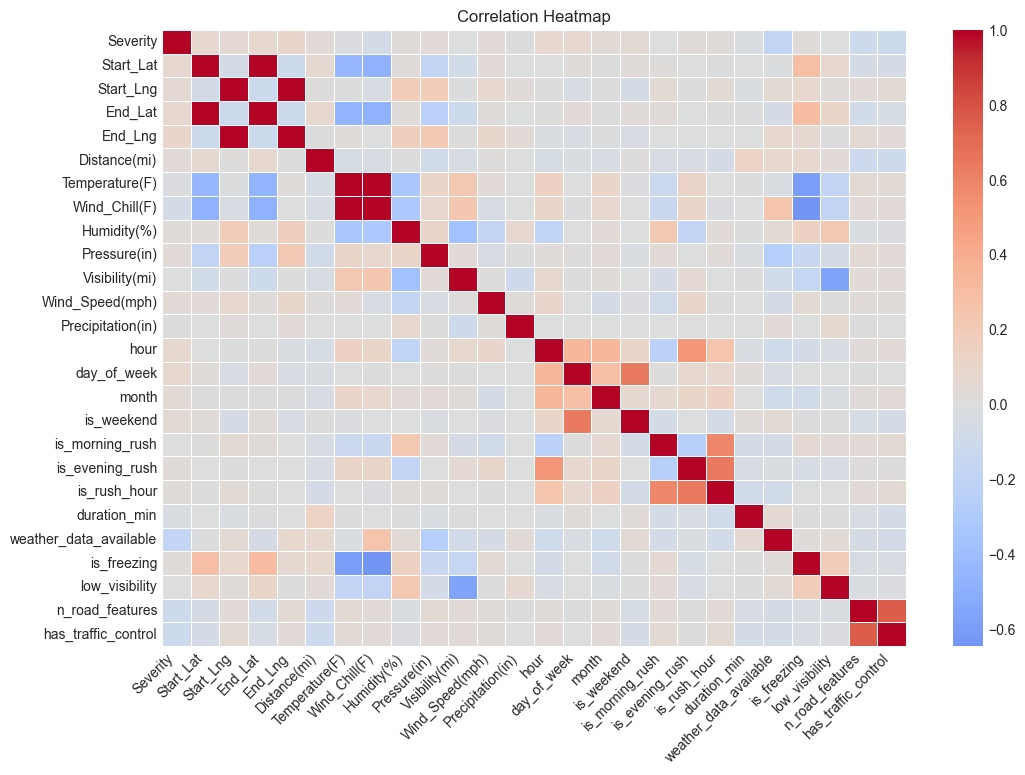

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_city = city_df.select_dtypes(include=['number'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_city.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Correlation Heatmap')
plt.show()

### Key Takeway: Temperature and Wind Chill show a very high correlation. The Start and End coordinates are highlily correlated too, might be due to similar locations as we talk within the group. The temporal features (hour, rush hour) show moderate relationships with each other too. I noticed severity has low correlation with most of the features, this could be because it was a complex, non-linear interations then? Possibly. 

In [78]:
city_df['Severity'].value_counts()

Severity
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64

In [79]:
# Check remaining missing values
missing_summary = city_df.isnull().sum().sort_values(ascending=False)
missing_summary.head(15)

End_Lng                  219978
End_Lat                  219978
Wind_Chill(F)            129188
Start_Time                47737
End_Time                  47737
duration_min              47737
Wind_Direction            11382
Weather_Condition         11300
Weather_Timestamp          7842
Civil_Twilight             1561
Sunrise_Sunset             1561
Nautical_Twilight          1561
Astronomical_Twilight      1561
Airport_Code               1514
Street                      654
dtype: int64

In [80]:
city_df[['Start_Time', 'End_Time']].dtypes

Start_Time    datetime64[us]
End_Time      datetime64[us]
dtype: object

In [81]:
city_df[['hour', 'day_of_week', 'month', 'is_rush_hour', 'duration_min']].head()

,hour,day_of_week,month,is_rush_hour,duration_min
0,13,1,10,0,124.666667
1,6,2,10,0,29.250000
2,14,6,8,0,105.000000
3,19,4,6,1,88.766667
4,12,4,3,0,22.500000


In [82]:
city_df.dtypes.value_counts()

str               19
float64           13
bool              13
int64             10
Int64              3
datetime64[us]     2
Name: count, dtype: int64

In [83]:
# If End_Lat/Lng missing → use Start_Lat/Lng
city_df['End_Lat'] = city_df['End_Lat'].fillna(city_df['Start_Lat'])
city_df['End_Lng'] = city_df['End_Lng'].fillna(city_df['Start_Lng'])

In [84]:
# Get all string (object) columns
string_cols = city_df.select_dtypes(include='object').columns

print(string_cols)

Index(['ID', 'Source', 'Description', 'Street', 'City', 'County', 'State',
       'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
       'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
       'weather_group'],
      dtype='str')


#### Need to ask the team if I should keep the string columns above, I don't want to drop anything without checking with everyone. 

- Would they help with the ML models or needed for CNN or NLP? 
- For weather, do we want to use the detailed text like weather condition or should we try to group any? I am just not sure if it would be better to simplify weather into categories.
- On the day/night features (sunrise_sunset, civil_twilight, nautical_twilight, astronomical_twlight), should we convert these like day to be 1 and night to be 0? 
- On the weather timestamp, do we need it? I know we have start time already. 